# Planejamento de rotas hospitalares

Este notebook reúne o fluxo completo de planejamento: leitura ou criação do cenário, diagnóstico dos dados, otimização, comparação experimental, visualização e geração de instruções operacionais. A proposta é que o processo possa ser acompanhado do início ao fim sem depender de um terminal.

Ao longo da execução, cada seção responde a uma pergunta diferente:

1. os dados são coerentes com a frota disponível?
2. como o algoritmo genético representa e avalia uma rota?
3. a busca está convergindo e a solução respeita as restrições?
4. o resultado é melhor que referências simples e estável entre sementes?
5. como transformar a solução em artefatos e instruções compreensíveis?

No VS Code ou Jupyter, selecione o kernel da `.venv` e execute as células em ordem. Depois de alterar o cenário ou algum parâmetro, execute novamente todas as células posteriores para evitar a comparação de resultados produzidos com configurações diferentes.


## 1. Preparação do ambiente

A primeira célula identifica automaticamente a raiz do repositório e instala o pacote em modo editável no kernel selecionado. Nesse modo, os módulos continuam apontando para o código em `src/hospital_routes`; portanto, uma alteração no projeto pode ser utilizada sem criar uma cópia separada do pacote.

Essa preparação também adiciona a pasta `src` ao caminho de importação da sessão. A célula pode ser executada novamente com segurança. Se os imports permanecerem carregando por muito tempo, confirme se o kernel escolhido pertence à `.venv` do projeto e reinicie a sessão antes de tentar outra vez.


In [1]:
from pathlib import Path
import subprocess
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-e', str(ROOT), '--quiet'])
sys.path.insert(0, str(ROOT / 'src'))
print(f'Projeto preparado em: {ROOT}')

Projeto preparado em: c:\Users\fdsam\Desktop\Felipe\FIAP\Tech_Challenge_2\tech_challenge_2


## 2. Importações

As importações refletem a separação de responsabilidades adotada no projeto:

- `models` e `io` representam e carregam o problema;
- `genetic` executa a otimização;
- `baselines` fornece abordagens de referência;
- `visualization` produz mapa e gráficos;
- `reporting` prepara o contexto e gera os relatórios.

Ao final, o notebook informa qual interpretador está em uso e apenas confirma se uma chave do Gemini foi localizada. O valor da credencial nunca é exibido.


In [2]:
import json
import random
import statistics
import time
from IPython.display import Markdown, clear_output, display
import matplotlib.pyplot as plt

from hospital_routes.baselines import brute_force, nearest_neighbor
from hospital_routes.genetic import GAConfig, GeneticOptimizer
from hospital_routes.io import load_problem, save_solution
from hospital_routes.models import Delivery, Depot, Problem, Vehicle
from hospital_routes.reporting import (GeminiReportGenerator, LocalReportGenerator, build_prompt, comparison_metrics, configured_gemini_key)
from hospital_routes.visualization import create_route_map, save_convergence_plot, save_route_map
print(f'Kernel: {sys.executable}')
print('Gemini configurado:', bool(configured_gemini_key()))

Kernel: c:\Users\fdsam\Desktop\Felipe\FIAP\Tech_Challenge_2\tech_challenge_2\.venv\Scripts\python.exe
Gemini configurado: True


## 3. Configuração do experimento

Os valores desta seção concentram as escolhas que normalmente são alteradas durante os testes. Isso permite comparar cenários sem modificar o código do algoritmo.

| Parâmetro | Significado | Efeito esperado |
|---|---|---|
| `USAR_CENARIO_PADRAO` | escolhe entre o JSON versionado e um cenário sintético | `True` favorece reprodutibilidade; `False` permite variar o problema |
| `NUMERO_ENTREGAS` e `NUMERO_VEICULOS` | dimensões do cenário sintético | mais entregas ampliam rapidamente o espaço de busca |
| `CAPACIDADE_KG` e `AUTONOMIA_KM` | limites dos veículos sintéticos | valores baixos aumentam a chance de inviabilidade |
| `TAMANHO_POPULACAO` | quantidade de indivíduos por geração | populações maiores exploram mais alternativas, com maior custo computacional |
| `GERACOES` | limite de evolução | oferece mais oportunidades de melhoria, embora possa ocorrer parada antecipada |
| `TAXA_CROSSOVER` | probabilidade de recombinar dois pais | controla a combinação de diferentes ordens de visita |
| `TAXA_MUTACAO` | probabilidade de alterar um descendente | ajuda a preservar diversidade e escapar de ótimos locais |
| `ELITISMO` | melhores indivíduos preservados | zero permite testar sem elitismo; valores positivos evitam perder boas soluções |
| `SEMENTE` | estado inicial do gerador pseudoaleatório | permite repetir o mesmo experimento |

Quando `USAR_CENARIO_PADRAO = True`, quantidade de entregas, quantidade de veículos, capacidade e autonomia são lidas de `data/deliveries.json`; os quatro valores sintéticos correspondentes não são utilizados. Os parâmetros do algoritmo genético continuam válidos nos dois modos.


In [3]:
USAR_CENARIO_PADRAO = True
NUMERO_ENTREGAS = 10
NUMERO_VEICULOS = 3
CAPACIDADE_KG = 55.0
AUTONOMIA_KM = 65.0

TAMANHO_POPULACAO = 120
GERACOES = 300
TAXA_CROSSOVER = 0.90
TAXA_MUTACAO = 0.20
ELITISMO = 4
SEMENTE = 42

## 4. Construção do cenário

O cenário é composto por um hospital, pelas entregas e pela frota. O hospital funciona como depósito: toda rota parte dele e retorna a ele, mas ele não é contado como entrega.

Cada entrega possui coordenadas em graus decimais, demanda total em quilogramas, tempo de serviço e prioridade. Neste projeto, prioridade `1` representa atendimento regular, `2` indica prioridade alta e `3` representa uma entrega crítica. A demanda descreve a carga total destinada ao ponto, e não o peso de uma unidade de medicamento.

No modo sintético, a mesma semente gera novamente posições, demandas e prioridades iguais. A listagem impressa após a célula serve como uma pequena auditoria do cenário efetivamente utilizado e facilita a conferência das coordenadas antes da otimização.


In [4]:
if USAR_CENARIO_PADRAO:
    problem = load_problem(ROOT / 'data' / 'deliveries.json')
else:
    rng = random.Random(SEMENTE)
    depot = Depot('Hospital Central', rng.uniform(-13.005, -12.94), rng.uniform(-38.53, -38.45))
    deliveries = tuple(
        Delivery(
            id=f'E{i + 1:02d}', name=f'Ponto {i + 1:02d}',
            latitude=rng.uniform(-13.05, -12.89), longitude=rng.uniform(-38.57, -38.33),
            demand_kg=round(rng.uniform(4, CAPACIDADE_KG * 0.30), 1),
            priority=rng.randint(1, 3), service_minutes=10,
        ) for i in range(NUMERO_ENTREGAS)
    )
    vehicles = tuple(Vehicle(f'VEIC-{i + 1:02d}', CAPACIDADE_KG, AUTONOMIA_KM) for i in range(NUMERO_VEICULOS))
    problem = Problem(depot, deliveries, vehicles)

print(f'Hospital: {problem.depot.latitude:.6f}, {problem.depot.longitude:.6f}')
print(f'Entregas: {len(problem.deliveries)} | Veículos: {len(problem.vehicles)}')
for delivery in problem.deliveries:
    print(f'{delivery.id}: ({delivery.latitude:.6f}, {delivery.longitude:.6f}) | {delivery.demand_kg:.1f} kg | prioridade {delivery.priority}')

Hospital: -12.971400, -38.501400
Entregas: 10 | Veículos: 3
E01: (-12.992400, -38.489400) | 18.0 kg | prioridade 3
E02: (-13.001400, -38.506800) | 12.0 kg | prioridade 2
E03: (-13.009300, -38.532700) | 16.0 kg | prioridade 1
E04: (-12.948600, -38.363800) | 20.0 kg | prioridade 3
E05: (-12.944100, -38.495100) | 14.0 kg | prioridade 2
E06: (-12.958500, -38.459100) | 22.0 kg | prioridade 1
E07: (-13.005800, -38.510800) | 8.0 kg | prioridade 3
E08: (-12.923800, -38.508400) | 10.0 kg | prioridade 1
E09: (-13.001100, -38.459000) | 13.0 kg | prioridade 2
E10: (-13.010200, -38.489300) | 7.0 kg | prioridade 3


### 4.1 Diagnóstico dos dados e viabilidade mínima

Antes de iniciar uma busca mais custosa, são verificadas duas condições necessárias:

- a soma das capacidades deve comportar a demanda total;
- a maior entrega deve caber em pelo menos um veículo.

Se uma dessas condições for falsa, o cenário já possui uma incompatibilidade evidente e deve ser revisto. Se ambas forem verdadeiras, ainda não há garantia de viabilidade: a divisão das cargas pode ser desfavorável e a autonomia depende da ordem e da distribuição espacial das visitas. Por isso, a confirmação definitiva ocorre somente após avaliar as rotas completas.


In [5]:
total_demand = sum(item.demand_kg for item in problem.deliveries)
total_capacity = sum(vehicle.capacity_kg for vehicle in problem.vehicles)
largest_demand = max(item.demand_kg for item in problem.deliveries)
largest_capacity = max(vehicle.capacity_kg for vehicle in problem.vehicles)
diagnostics = {
    'demanda_total_kg': total_demand,
    'capacidade_total_kg': total_capacity,
    'capacidade_agregada_suficiente': total_demand <= total_capacity,
    'maior_entrega_atendivel': largest_demand <= largest_capacity,
}
diagnostics

{'demanda_total_kg': 140.0,
 'capacidade_total_kg': 145.0,
 'capacidade_agregada_suficiente': True,
 'maior_entrega_atendivel': True}

## 5. Configuração do algoritmo genético

Cada indivíduo da população é uma permutação dos índices das entregas. Um decodificador percorre essa ordem e distribui as visitas entre os veículos, levando em conta a ocupação da carga, a distância projetada e possíveis violações. Essa estratégia preserva uma representação típica do TSP e permite ampliar o problema para múltiplos veículos.

A função de aptidão é minimizada e pode ser resumida por:

\[
f(x) = D + \alpha P + \beta E_c + \gamma E_a
\]

`D` representa a distância total; `P`, a distância acumulada até cada entrega ponderada por sua prioridade; `E_c` e `E_a`, os excessos de capacidade e autonomia. As penalidades elevadas tornam uma violação operacional mais relevante do que uma pequena redução de percurso.

A evolução utiliza seleção por torneio, crossover ordenado (OX1), mutações por troca ou inversão e elitismo configurável. O vizinho mais próximo é calculado antes da busca para estabelecer uma referência simples com a mesma função de aptidão.


In [6]:
config = GAConfig(
    population_size=TAMANHO_POPULACAO, generations=GERACOES,
    crossover_rate=TAXA_CROSSOVER, mutation_rate=TAXA_MUTACAO,
    elite_size=ELITISMO, seed=SEMENTE,
)
optimizer = GeneticOptimizer(problem, config)
baseline = nearest_neighbor(optimizer)
print(f'Fitness do vizinho mais próximo: {baseline.fitness:.2f}')

Fitness do vizinho mais próximo: 150.35


## 6. Evolução e acompanhamento da convergência

Durante a evolução, a saída é atualizada a cada dez gerações. Os painéis usam escalas independentes para que cada comportamento permaneça legível:

- **melhor fitness:** acompanha a melhor alternativa da geração;
- **fitness médio:** resume a qualidade de toda a população.

Como o objetivo é minimizar, uma queda indica melhoria. Uma diferença ampla entre a média e o melhor valor sugere que ainda existe diversidade na população; a aproximação entre as curvas costuma indicar maior concentração em soluções semelhantes. A estabilização não prova que o ótimo global foi encontrado: ela mostra apenas que a configuração atual deixou de produzir melhorias relevantes.

Além do limite de gerações, o algoritmo interrompe a execução quando alcança o número configurado de gerações sem melhora. Assim, o total executado pode ser menor que `GERACOES`.


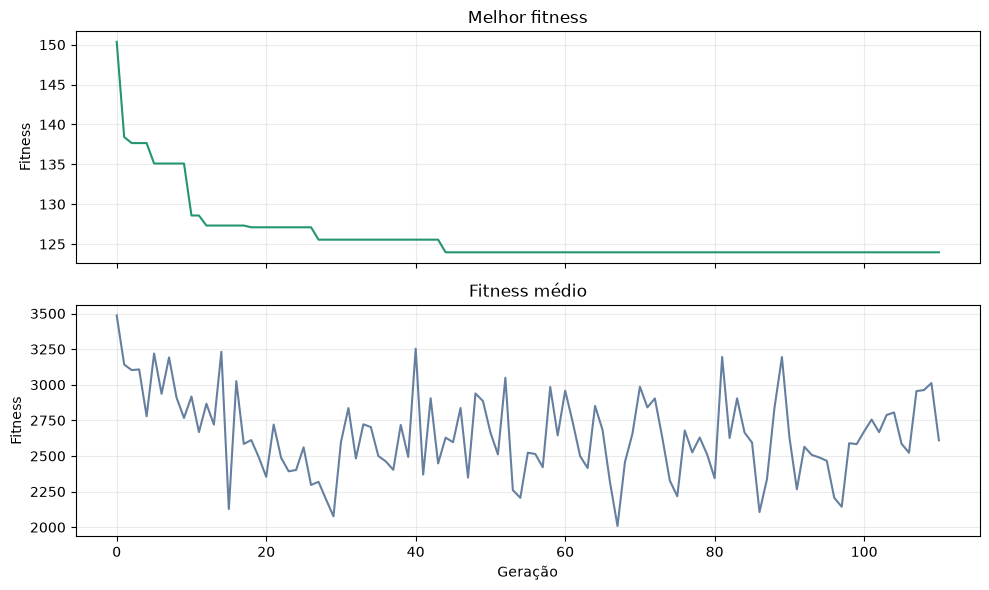

Geração 110 | melhor: 123.97 | média: 2609.78
Concluído em 115 gerações.


In [7]:
solution = None
for stats, solution in optimizer.evolve():
    if stats.generation % 10 == 0 or stats.generation == GERACOES - 1:
        clear_output(wait=True)
        generations = [item.generation for item in optimizer.history]
        fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
        axes[0].plot(generations, [item.best for item in optimizer.history], color='#24966f')
        axes[0].set_title('Melhor fitness'); axes[0].set_ylabel('Fitness'); axes[0].grid(alpha=.25)
        axes[1].plot(generations, [item.mean for item in optimizer.history], color='#657f9f')
        axes[1].set_title('Fitness médio'); axes[1].set_xlabel('Geração'); axes[1].set_ylabel('Fitness'); axes[1].grid(alpha=.25)
        fig.tight_layout(); display(fig); plt.close(fig)
        print(f'Geração {stats.generation} | melhor: {stats.best:.2f} | média: {stats.mean:.2f}')

assert solution is not None
print(f'Concluído em {len(optimizer.history)} gerações.')

## 7. Análise da solução

Esta etapa separa métricas que respondem a perguntas diferentes. A distância total descreve o percurso, enquanto o fitness também incorpora prioridade e penalidades. Por esse motivo, a rota de menor distância nem sempre é a de menor fitness.

A solução é considerada viável somente quando nenhum veículo excede capacidade ou autonomia. Para cada rota são exibidos sequência de paradas, distância e carga; “não utilizado” apenas indica que o veículo ficou sem entregas, o que não constitui uma violação.

A redução percentual é calculada em relação ao vizinho mais próximo. Valor positivo indica melhora do algoritmo genético; valor negativo indica que a referência obteve fitness menor naquela execução. A comparação permanece fundamentada porque as duas soluções são avaliadas pelo mesmo objeto `GeneticOptimizer`.


In [8]:
improvement = 100 * (baseline.fitness - solution.fitness) / baseline.fitness
print(f'Fitness final: {solution.fitness:.2f}')
print(f'Distância total: {solution.total_distance_km:.2f} km')
print(f'Solução viável: {solution.feasible}')
print(f'Redução frente ao vizinho mais próximo: {improvement:.2f}%')
for i, route in enumerate(solution.routes):
    metric = solution.metrics[i]
    stops = ' → '.join(problem.deliveries[j].id for j in route) or 'não utilizado'
    print(f'{problem.vehicles[i].id}: {stops} | {metric.distance_km:.2f} km | {metric.load_kg:.1f} kg')
comparison = comparison_metrics(solution, baseline)
comparison

Fitness final: 123.97
Distância total: 67.58 km
Solução viável: True
Redução frente ao vizinho mais próximo: 17.55%
VAN-01: E01 → E02 → E07 → E03 | 13.27 km | 54.0 kg
VAN-02: E05 → E08 → E04 | 36.83 km | 44.0 kg
UTIL-03: E10 → E09 → E06 | 17.48 km | 42.0 kg


{'referencia': 'vizinho mais próximo',
 'fitness_referencia': 150.3531,
 'fitness_solucao': 123.9669,
 'reducao_fitness_percentual': 17.55,
 'distancia_referencia_km': 83.6775,
 'distancia_solucao_km': 67.5844,
 'reducao_distancia_km': 16.0931,
 'reducao_distancia_percentual': 19.23,
 'observacao': 'Não há dados de velocidade, tempo real ou custo monetário; essas economias não devem ser estimadas.'}

## 8. Comparação experimental e robustez

Uma única execução não é suficiente para avaliar uma meta-heurística. A comparação foi dividida em duas partes complementares:

1. **instância reduzida:** as oito primeiras entregas são avaliadas por vizinho mais próximo, força bruta e algoritmo genético. A força bruta enumera `8! = 40.320` permutações e fornece o melhor resultado no espaço avaliado;
2. **cenário completo:** cinco sementes medem quanto o resultado varia quando a população inicial e as operações aleatórias mudam.

Todas as abordagens utilizam a mesma função de aptidão dentro de cada instância. Os tempos medidos com `perf_counter` servem apenas para comparar esta execução no equipamento atual; não representam garantia de desempenho em outro ambiente.


In [9]:
small_problem = Problem(problem.depot, problem.deliveries[:8], problem.vehicles)
small_optimizer = GeneticOptimizer(
    small_problem, GAConfig(population_size=80, generations=150, stagnation_limit=50, seed=42)
)
times = {}
start = time.perf_counter(); nearest_small = nearest_neighbor(small_optimizer); times['vizinho'] = time.perf_counter() - start
start = time.perf_counter(); exact_small = brute_force(small_optimizer, max_deliveries=8); times['forca_bruta'] = time.perf_counter() - start
start = time.perf_counter(); genetic_small = small_optimizer.run(); times['genetico'] = time.perf_counter() - start
print('Instância reduzida (8 entregas)')
for name, item in [('Vizinho mais próximo', nearest_small), ('Força bruta', exact_small), ('Algoritmo genético', genetic_small)]:
    key = {'Vizinho mais próximo':'vizinho','Força bruta':'forca_bruta','Algoritmo genético':'genetico'}[name]
    print(f'{name}: fitness={item.fitness:.2f}; distância={item.total_distance_km:.2f} km; tempo={times[key]:.4f} s')
print('GA atingiu o fitness da força bruta:', abs(genetic_small.fitness - exact_small.fitness) < 1e-9)

Instância reduzida (8 entregas)
Vizinho mais próximo: fitness=123.99; distância=72.62 km; tempo=0.0006 s
Força bruta: fitness=91.22; distância=54.72 km; tempo=1.6043 s
Algoritmo genético: fitness=91.22; distância=54.72 km; tempo=0.4084 s
GA atingiu o fitness da força bruta: True


In [10]:
seed_results = []
for seed in (7, 21, 42, 84, 123):
    experiment = GeneticOptimizer(
        problem, GAConfig(population_size=80, generations=150, stagnation_limit=50, seed=seed)
    )
    reference = nearest_neighbor(experiment)
    start = time.perf_counter(); result = experiment.run(); elapsed = time.perf_counter() - start
    reduction = 100 * (reference.fitness - result.fitness) / reference.fitness
    seed_results.append((seed, result.fitness, result.total_distance_km, result.feasible, elapsed, reduction))
for row in seed_results:
    print(f'seed={row[0]} | fitness={row[1]:.2f} | distância={row[2]:.2f} km | viável={row[3]} | tempo={row[4]:.3f} s | redução={row[5]:.2f}%')
print(f'Fitness médio: {statistics.mean(r[1] for r in seed_results):.2f}')
print(f'Desvio-padrão do fitness: {statistics.pstdev(r[1] for r in seed_results):.2f}')
print(f'Redução média frente à referência: {statistics.mean(r[5] for r in seed_results):.2f}%')

seed=7 | fitness=123.97 | distância=67.58 km | viável=True | tempo=0.504 s | redução=17.55%
seed=21 | fitness=123.97 | distância=67.58 km | viável=True | tempo=0.489 s | redução=17.55%
seed=42 | fitness=126.92 | distância=65.34 km | viável=True | tempo=0.505 s | redução=15.58%
seed=84 | fitness=127.44 | distância=68.54 km | viável=True | tempo=0.413 s | redução=15.24%
seed=123 | fitness=123.97 | distância=67.58 km | viável=True | tempo=0.639 s | redução=17.55%
Fitness médio: 125.25
Desvio-padrão do fitness: 1.58
Redução média frente à referência: 16.70%


### 8.1 Como interpretar o comparativo

Na instância reduzida, atingir o mesmo fitness da força bruta é uma evidência de qualidade para aquele recorte, e não uma prova de que o algoritmo genético sempre encontra o ótimo. No cenário completo, média e desvio-padrão mostram o comportamento conjunto das sementes: média menor indica melhor resultado global, enquanto desvio-padrão baixo sugere maior estabilidade.

Também é importante observar a coluna `viável`. Um fitness numericamente menor não deve ser aceito de forma isolada se houver excesso de carga ou autonomia. Por fim, o tempo de execução deve ser analisado junto com o tamanho da instância e a qualidade obtida; métodos exatos se tornam rapidamente impraticáveis conforme o número de entregas aumenta.


## 9. Geração dos entregáveis

Depois da análise, a solução é transformada em artefatos que podem ser inspecionados fora do notebook:

| Arquivo | Conteúdo |
|---|---|
| `solution.json` | rotas, métricas, fitness e viabilidade em formato estruturado |
| `routes_map.html` | mapa interativo com hospital, paradas e cores por veículo |
| `convergence.png` | painéis finais de melhor fitness e fitness médio |
| `daily_report.md` | instruções operacionais produzidas pelo Gemini ou pelo gerador local |
| `comparison.json` | métricas mensuráveis frente ao vizinho mais próximo |

Os arquivos são gravados em `outputs` e substituem versões anteriores com o mesmo nome. O JSON da solução permanece como fonte de verdade; o relatório textual é uma forma de comunicação derivada desses dados.


In [11]:
OUTPUT = ROOT / 'outputs'
OUTPUT.mkdir(exist_ok=True)
save_solution(OUTPUT / 'solution.json', problem, solution)
save_route_map(problem, solution, OUTPUT / 'routes_map.html')
save_convergence_plot(optimizer.history, OUTPUT / 'convergence.png')
try:
    report = GeminiReportGenerator().generate(problem, solution, comparison=comparison)
    report_source = 'Gemini'
except RuntimeError as error:
    report = LocalReportGenerator().generate(problem, solution, comparison=comparison)
    report_source = f'gerador local; Gemini indisponível: {error}'
(OUTPUT / 'daily_report.md').write_text(report, encoding='utf-8')
(OUTPUT / 'comparison.json').write_text(json.dumps(comparison, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Origem do relatório: {report_source}')
print('Arquivos gerados:')
for name in ('solution.json', 'routes_map.html', 'convergence.png', 'daily_report.md', 'comparison.json'):
    print(' -', OUTPUT / name)

Origem do relatório: Gemini
Arquivos gerados:
 - c:\Users\fdsam\Desktop\Felipe\FIAP\Tech_Challenge_2\tech_challenge_2\outputs\solution.json
 - c:\Users\fdsam\Desktop\Felipe\FIAP\Tech_Challenge_2\tech_challenge_2\outputs\routes_map.html
 - c:\Users\fdsam\Desktop\Felipe\FIAP\Tech_Challenge_2\tech_challenge_2\outputs\convergence.png
 - c:\Users\fdsam\Desktop\Felipe\FIAP\Tech_Challenge_2\tech_challenge_2\outputs\daily_report.md
 - c:\Users\fdsam\Desktop\Felipe\FIAP\Tech_Challenge_2\tech_challenge_2\outputs\comparison.json


## 10. Mapa e relatório no notebook

O mapa permite conferir visualmente a distribuição das entregas e a ordem das paradas. As linhas ligam as coordenadas diretamente e representam distâncias geodésicas; elas não reproduzem ruas, trânsito ou sentido das vias.

Logo abaixo do mapa, o relatório operacional é exibido no próprio notebook. Se o Gemini estiver disponível, o texto será generativo; caso contrário, o gerador local apresentará as mesmas rotas de forma determinística e auditável.


In [12]:
route_map = create_route_map(problem, solution)
display(route_map)
display(Markdown(report))


Como analista de logística hospitalar, apresento as instruções objetivas de rota por veículo e o resumo diário de eficiência, baseados estritamente nos dados fornecidos.

---

### **Instruções por Veículo**

#### **VEÍCULO: VAN-01**
*   **Capacidade do veículo:** 55,0 kg
*   **Distância máxima permitida:** 65,0 km
*   **Ponto de Partida:** Hospital Central (Latitude: -12.9714, Longitude: -38.5014)

**Sequência de Paradas:**
1.  **UPA Brotas (E01)**
    *   Coordenadas: Latitude -12.9924, Longitude -38.4894
    *   Demanda a entregar: 18,0 kg
    *   Tempo de serviço: 15 minutos
    *   Prioridade: 3
2.  **UBS Federação (E02)**
    *   Coordenadas: Latitude -13.0014, Longitude -38.5068
    *   Demanda a entregar: 12,0 kg
    *   Tempo de serviço: 12 minutos
    *   Prioridade: 2
3.  **Atendimento Ondina (E07)**
    *   Coordenadas: Latitude -13.0058, Longitude -38.5108
    *   Demanda a entregar: 8,0 kg
    *   Tempo de serviço: 8 minutos
    *   Prioridade: 3
4.  **Unidade Barra (E03)**
    *   Coordenadas: Latitude -13.0093, Longitude -38.5327
    *   Demanda a entregar: 16,0 kg
    *   Tempo de serviço: 10 minutos
    *   Prioridade: 1

**Métricas da Rota VAN-01:**
*   Distância percorrida: 13,27 km
*   Carga total transportada: 54,0 kg
*   Atraso de prioridade (*priority delay*): 41,88
*   **Restrições violadas:** Nenhuma (Excesso de capacidade: 0,0 kg | Excesso de autonomia: 0,0 km)

---

#### **VEÍCULO: VAN-02**
*   **Capacidade do veículo:** 45,0 kg
*   **Distância máxima permitida:** 55,0 km
*   **Ponto de Partida:** Hospital Central (Latitude: -12.9714, Longitude: -38.5014)

**Sequência de Paradas:**
1.  **UBS Liberdade (E05)**
    *   Coordenadas: Latitude -12.9441, Longitude -38.4951
    *   Demanda a entregar: 14,0 kg
    *   Tempo de serviço: 10 minutos
    *   Prioridade: 2
2.  **UBS Bonfim (E08)**
    *   Coordenadas: Latitude -12.9238, Longitude -38.5084
    *   Demanda a entregar: 10,0 kg
    *   Tempo de serviço: 10 minutos
    *   Prioridade: 1
3.  **Unidade Itapuã (E04)**
    *   Coordenadas: Latitude -12.9486, Longitude -38.3638
    *   Demanda a entregar: 20,0 kg
    *   Tempo de serviço: 18 minutos
    *   Prioridade: 3

**Métricas da Rota VAN-02:**
*   Distância percorrida: 36,83 km
*   Carga total transportada: 44,0 kg
*   Atraso de prioridade (*priority delay*): 77,12
*   **Restrições violadas:** Nenhuma (Excesso de capacidade: 0,0 kg | Excesso de autonomia: 0,0 km)

---

#### **VEÍCULO: UTIL-03**
*   **Capacidade do veículo:** 45,0 kg
*   **Distância máxima permitida:** 45,0 km
*   **Ponto de Partida:** Hospital Central (Latitude: -12.9714, Longitude: -38.5014)

**Sequência de Paradas:**
1.  **Atendimento Rio Vermelho (E10)**
    *   Coordenadas: Latitude -13.0102, Longitude -38.4893
    *   Demanda a entregar: 7,0 kg
    *   Tempo de serviço: 8 minutos
    *   Prioridade: 3
2.  **Unidade Pituba (E09)**
    *   Coordenadas: Latitude -13.0011, Longitude -38.459
    *   Demanda a entregar: 13,0 kg
    *   Tempo de serviço: 10 minutos
    *   Prioridade: 2
3.  **Unidade Cabula (E06)**
    *   Coordenadas: Latitude -12.9585, Longitude -38.4591
    *   Demanda a entregar: 22,0 kg
    *   Tempo de serviço: 12 minutos
    *   Prioridade: 1

**Métricas da Rota UTIL-03:**
*   Distância percorrida: 17,48 km
*   Carga total transportada: 42,0 kg
*   Atraso de prioridade (*priority delay*): 42,10
*   **Restrições violadas:** Nenhuma (Excesso de capacidade: 0,0 kg | Excesso de autonomia: 0,0 km)

---

### **Sinalização de Restrições Violadas**
*   **Status da solução:** Viável.
*   **Restrições violadas no sistema:** Nenhuma. Todos os veículos operaram dentro de seus limites de capacidade de carga (kg) e autonomia de distância (km).

---

### **Resumo Diário de Eficiência**

*   **Distância total percorrida na solução:** 67,58 km (67,5844 km detalhados)
*   **Distância do método de referência (vizinho mais próximo):** 83,6775 km
*   **Redução absoluta de distância:** 16,0931 km
*   **Redução percentual de distância:** 19,23%
*   **Fitness da solução atual:** 123,9669
*   **Fitness da referência (vizinho mais próximo):** 150,3531
*   **Redução percentual de fitness:** 17,55%

*Observação analítica:* Não há dados de velocidade, tempo real de trânsito ou custo monetário associados ao cenário; portanto, estimativas de tempo de viagem ou economias financeiras não foram calculadas.

## 11. Integração com a LLM

A LLM participa somente depois que a otimização termina. Ela não escolhe veículos, não altera a ordem das visitas e não decide se uma rota é viável. Seu papel é transformar a solução estruturada em instruções, sínteses e respostas mais fáceis de consultar.

O prompt contém papel, tarefa, idioma, regras contra informações inventadas e o contexto em JSON. Também proíbe converter distância em tempo ou dinheiro sem dados observados. Esse envio direto da solução funciona como aterramento: a resposta deve permanecer vinculada aos valores calculados.

Não há RAG nesta versão porque não existe uma coleção de protocolos ou manuais a ser pesquisada. Caso esse acervo seja incorporado futuramente, seus documentos deverão ter fonte e versão identificáveis. Independentemente da técnica, qualquer saída generativa precisa de revisão humana antes de orientar uma operação real.


In [13]:
prompt_preview = build_prompt(problem, solution, comparison=comparison)
print('Caracteres do prompt:', len(prompt_preview))
print('Instruções de controle presentes:', all(term in prompt_preview for term in ('Não invente', 'Não converta', 'Contexto estruturado')))
print('O contexto enviado contém apenas dados operacionais fictícios e a solução calculada.')

Caracteres do prompt: 4468
Instruções de controle presentes: True
O contexto enviado contém apenas dados operacionais fictícios e a solução calculada.


### 11.1 Relatório semanal e perguntas em linguagem natural

As chamadas adicionais ficam desativadas por padrão para que **Executar tudo** não dependa de cota, rede ou disponibilidade do provedor. Ao habilitá-las, o mesmo contexto é reutilizado para produzir uma análise semanal e responder a uma pergunta operacional.

Essas respostas complementam a apresentação dos resultados, mas não substituem `solution.json`. Se a API estiver indisponível ou recusar a requisição, a célula informa o problema sem interromper o restante do notebook. Nenhuma credencial é impressa ou armazenada nas saídas.


In [15]:
EXECUTAR_TAREFAS_ADICIONAIS_LLM = True
if EXECUTAR_TAREFAS_ADICIONAIS_LLM:
    try:
        generator = GeminiReportGenerator()
        weekly_report = generator.generate(problem, solution, task='weekly', comparison=comparison)
        question = 'Quais veículos atendem entregas de prioridade crítica?'
        answer = generator.generate(
            problem, solution, task=f'Responda de forma objetiva: {question}', comparison=comparison
        )
        display(Markdown(weekly_report))
        display(Markdown('**Pergunta:** ' + question + '\n\n**Resposta:** ' + answer))
    except RuntimeError as error:
        print(f'Não foi possível executar as tarefas adicionais: {error}')
else:
    print('Chamadas adicionais desativadas. Altere a variável para demonstrar relatório semanal e perguntas.')


### Relatório Semanal de Logística Hospitalar

**Depósito de Origem:** Hospital Central (Latitude: -12.9714, Longitude: -38.5014)  
**Distância Total Planejada:** 67,58 km  
**Status da Solução:** Viável

---

#### 1. Detalhamento das Rotas Executadas

##### **Rota 1: Veículo VAN-01**
*   **Especificações do Veículo:** Capacidade máxima de 55,0 kg | Autonomia máxima de 65,0 km
*   **Métricas da Rota:**
    *   Distância percorrida: 13,27 km
    *   Carga total transportada: 54,0 kg
    *   Atraso de prioridade (*priority delay*): 41,88
*   **Sequência de Paradas:**
    1.  **E01 - UPA Brotas** (Demanda: 18,0 kg | Prioridade: 3 | Tempo de serviço: 15 min)
    2.  **E02 - UBS Federação** (Demanda: 12,0 kg | Prioridade: 2 | Tempo de serviço: 12 min)
    3.  **E07 - Atendimento Ondina** (Demanda: 8,0 kg | Prioridade: 3 | Tempo de serviço: 8 min)
    4.  **E03 - Unidade Barra** (Demanda: 16,0 kg | Prioridade: 1 | Tempo de serviço: 10 min)

##### **Rota 2: Veículo VAN-02**
*   **Especificações do Veículo:** Capacidade máxima de 45,0 kg | Autonomia máxima de 55,0 km
*   **Métricas da Rota:**
    *   Distância percorrida: 36,83 km
    *   Carga total transportada: 44,0 kg
    *   Atraso de prioridade (*priority delay*): 77,12
*   **Sequência de Paradas:**
    1.  **E05 - UBS Liberdade** (Demanda: 14,0 kg | Prioridade: 2 | Tempo de serviço: 10 min)
    2.  **E08 - UBS Bonfim** (Demanda: 10,0 kg | Prioridade: 1 | Tempo de serviço: 10 min)
    3.  **E04 - Unidade Itapuã** (Demanda: 20,0 kg | Prioridade: 3 | Tempo de serviço: 18 min)

##### **Rota 3: Veículo UTIL-03**
*   **Especificações do Veículo:** Capacidade máxima de 45,0 kg | Autonomia máxima de 45,0 km
*   **Métricas da Rota:**
    *   Distância percorrida: 17,48 km
    *   Carga total transportada: 42,0 kg
    *   Atraso de prioridade (*priority delay*): 42,10
*   **Sequência de Paradas:**
    1.  **E10 - Atendimento Rio Vermelho** (Demanda: 7,0 kg | Prioridade: 3 | Tempo de serviço: 8 min)
    2.  **E09 - Unidade Pituba** (Demanda: 13,0 kg | Prioridade: 2 | Tempo de serviço: 10 min)
    3.  **E06 - Unidade Cabula** (Demanda: 22,0 kg | Prioridade: 1 | Tempo de serviço: 12 min)

---

#### 2. Análise de Restrições

*   **Restrições de Capacidade de Carga Violadas:** Nenhuma.
    *   VAN-01: Excesso de 0,0 kg (Carga: 54,0 kg / Limite: 55,0 kg)
    *   VAN-02: Excesso de 0,0 kg (Carga: 44,0 kg / Limite: 45,0 kg)
    *   UTIL-03: Excesso de 0,0 kg (Carga: 42,0 kg / Limite: 45,0 kg)
*   **Restrições de Autonomia de Distância Violadas:** Nenhuma.
    *   VAN-01: Excesso de 0,0 km (Distância: 13,27 km / Limite: 65,0 km)
    *   VAN-02: Excesso de 0,0 km (Distância: 36,83 km / Limite: 55,0 km)
    *   UTIL-03: Excesso de 0,0 km (Distância: 17,48 km / Limite: 45,0 km)

---

#### 3. Comparação de Eficiência

Em comparação com o método de referência ("vizinho mais próximo"):
*   **Redução de Distância:** Redução de 16,09 km (de 83,68 km na referência para 67,58 km na solução atual), o que representa uma diminuição de **19,23%** na distância total percorrida.
*   **Redução de Fitness:** Redução de 17,55% (de 150,35 na referência para 123,97 na solução atual).

*Nota de restrição analítica: Devido à ausência de dados sobre velocidade média, tempos de trânsito reais ou custos operacionais por quilômetro, não são apresentadas estimativas de tempo total de viagem ou de economia financeira.*

---

#### 4. Sugestões Prudentes de Melhoria

1.  **Reavaliação do Sequenciamento por Prioridade:** 
    *   Nas três rotas, os pontos de maior prioridade (Prioridade 1) são atendidos no final ou no meio do percurso (E03 é a 4ª parada na Rota 1; E08 é a 2ª parada na Rota 2; E06 é a 3ª parada na Rota 3). Isso gera os índices de atraso de prioridade registrados (41,88, 77,12 e 42,10). Recomenda-se testar um reordenamento que posicione os pontos de Prioridade 1 no início das rotas, monitorando se essa alteração mantém a viabilidade de distância e capacidade.
2.  **Monitoramento de Margem de Carga:**
    *   Os veículos VAN-01 e VAN-02 operam muito próximos de seus limites de capacidade de carga, com folgas de apenas 1,0 kg em cada veículo (ocupação de 98,1% e 97,7%, respectivamente). Recomenda-se monitorar rigorosamente as oscilações de demanda diárias dessas unidades para evitar que variações sazonais causem a violação da capacidade máxima dos veículos.

**Pergunta:** Quais veículos atendem entregas de prioridade crítica?

**Resposta:** Com base exclusivamente nos dados fornecidos, os veículos que atendem as entregas de prioridade crítica são:

*   **VAN-01**
*   **VAN-02**
*   **UTIL-03**

**Observação sobre os dados:** O contexto fornecido não define explicitamente qual valor numérico (1, 2 ou 3) corresponde à "prioridade crítica". No entanto, todos os três veículos listados realizam entregas em todos os níveis de prioridade existentes no relatório (prioridades 1, 2 e 3). Portanto, independentemente de qual número represente a prioridade crítica, todos os veículos a atendem.

---

**Restrições violadas:**
*   **Nenhuma restrição foi violada.** A solução é classificada como viável (`solucao_viavel: true`), e todos os veículos operam com excesso de capacidade de carga e de autonomia de distância iguais a zero (`capacity_excess_kg: 0.0` e `autonomy_excess_km: 0.0`).

## 12. Síntese metodológica

Os resultados devem ser interpretados em três níveis:

1. **validade computacional:** testes verificam entidades, distâncias, operadores, restrições, reprodutibilidade e integração dos relatórios;
2. **qualidade experimental:** baselines, força bruta reduzida e múltiplas sementes ajudam a avaliar qualidade e estabilidade, sem afirmar que o ótimo global foi encontrado no cenário completo;
3. **validade operacional:** depende da qualidade das coordenadas, demandas, prioridades e limites informados.

A solução oferece uma base reproduzível para experimentação e demonstra como integrar otimização evolutiva, visualização e geração textual fundamentada. Para uma aplicação operacional seriam necessários, entre outros elementos, uma matriz viária, tempos históricos, janelas de atendimento, custos observados, regras institucionais e governança dos dados.

Ao registrar os parâmetros, a semente e os artefatos de cada execução, torna-se possível explicar não apenas qual rota foi encontrada, mas também sob quais condições o resultado foi produzido.
